In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [3]:
ces = pd.read_csv('cces_example_data.csv')
ces.head()

,pew_religimp,pew_churatd,sex,educ,nonwhite,age,faminc_new,pid3,ideo5,QueerPhobia,...,InterGBiasParty,InterGBiasCand,InterGBiasSup,LibMediaUse,ConMediaUse,Real_Threat,Symb_Threat,Evaluation,teamweight,caseid
0,2,6,2,2,1,56,6,1,1,1.000000,...,-99,-99,-96,2.666667,1.000000,5.00,4.857143,0,0.505028,1231308943
1,2,4,2,5,1,53,13,1,2,3.000000,...,-100,-100,-100,2.000000,2.000000,5.00,5.000000,0,0.852381,1232300315
2,1,2,1,2,1,69,10,2,5,4.333333,...,99,99,96,1.000000,1.000000,5.00,5.000000,2,1.320189,1232358697
3,2,3,1,6,1,76,97,1,3,1.000000,...,-86,-91,-89,4.666667,1.333333,4.25,4.428571,0,0.519198,1232540961
4,4,5,2,6,1,83,4,1,2,1.000000,...,-80,-88,-87,4.666667,3.666667,4.25,5.000000,0,1.154005,1232580601


In [4]:
ces['ideo5'].value_counts()

ideo5
3    227
4    128
2    124
1     83
5     74
6     23
Name: count, dtype: int64

In [5]:
ces_fixed = ces[ces['ideo5'] != 6]
ces_fixed.shape

(636, 21)

In [6]:
ces_fixed['pid3'].value_counts()

pid3
1    244
3    220
2    172
Name: count, dtype: int64

In [7]:
ces_fixed['pid3_c'] = ces_fixed['pid3'].astype('category')

C:\Users\dsilva2\AppData\Local\Temp\ipykernel_15064\3445400926.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ces_fixed['pid3_c'] = ces_fixed['pid3'].astype('category')


In [8]:
ces_fixed['sex'].value_counts()

sex
2    348
1    288
Name: count, dtype: int64

In [9]:
ces_fixed['sex_c'] = ces_fixed['sex'].astype('category')

C:\Users\dsilva2\AppData\Local\Temp\ipykernel_15064\405867486.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ces_fixed['sex_c'] = ces_fixed['sex'].astype('category')


In [12]:
pid_map = {1: 'Democratic', 2: 'Republican', 3: 'Independent'}
sex_map = {1: 'Male', 2: 'Female'}

ces_fixed['pid3_c'] = ces_fixed['pid3_c'].cat.rename_categories(pid_map)
ces_fixed['sex_c'] = ces_fixed['sex_c'].cat.rename_categories(sex_map)

C:\Users\dsilva2\AppData\Local\Temp\ipykernel_15064\767907184.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ces_fixed['pid3_c'] = ces_fixed['pid3_c'].cat.rename_categories(pid_map)
C:\Users\dsilva2\AppData\Local\Temp\ipykernel_15064\767907184.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ces_fixed['sex_c'] = ces_fixed['sex_c'].cat.rename_categories(sex_map)


In [11]:
ces_fixed['pid3_c'].value_counts()

pid3_c
Democratic     244
Independent    220
Republican     172
Name: count, dtype: int64

In [13]:
model1 = smf.ols("InterGBiasParty ~ ideo5", data = ces_fixed)

In [14]:
fit1 = model1.fit()
fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        InterGBiasParty   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     579.1
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           2.14e-91
Time:                        19:28:22   Log-Likelihood:                -3369.9
No. Observations:                 636   AIC:                             6744.
Df Residuals:                     634   BIC:                             6753.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -125.2957      5.234    -23.939      0.000    -135.573    -115.018
ideo5         39.3363      1.635     24.064      0.000      36.126      42.546
==============================================================================
Omnibus:                        2.233   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.327   Jarque-Bera (JB):                2.265
Skew:                          -0.143   Prob(JB):                        0.322
Kurtosis:                       2.942   Cond. No.                         9.46
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

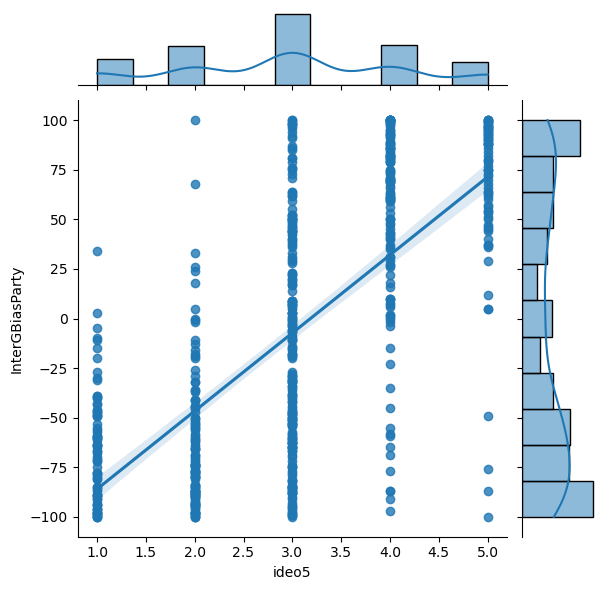

In [15]:
sns.jointplot(kind = 'reg', data = ces_fixed,
              x = 'ideo5', y = 'InterGBiasParty')
plt.show()

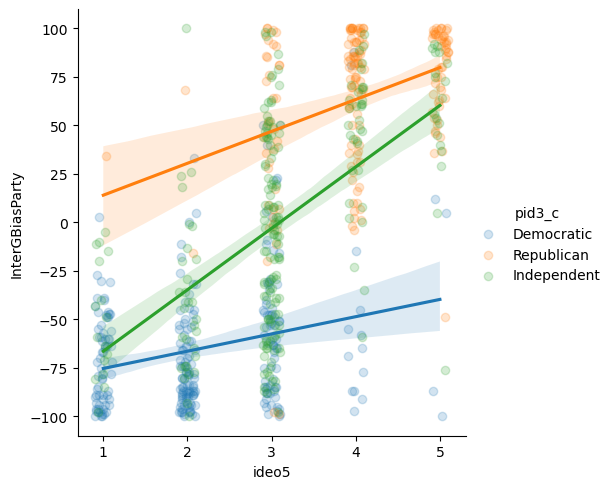

In [20]:
sns.lmplot(data = ces_fixed,
           x = 'ideo5', y = 'InterGBiasParty',
          hue = 'pid3_c', x_jitter = .1,
          scatter_kws={'alpha':0.2})
plt.show()